In [18]:
# 1. Import các thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt

# Đọc file dữ liệu Excel vào DataFrame
df = pd.read_excel('/content/ecommerce_sales_data.xlsx')

# 2. Hiển thị 7 dòng đầu tiên và 5 dòng cuối cùng
print("--- 7 DÒNG ĐẦU TIÊN ---")
display(df.head(7))

print("\n--- 5 DÒNG CUỐI CÙNG ---")
display(df.tail(5))

# 3. Sử dụng phương thức thích hợp để in ra thông tin tổng quan
print("\n--- THÔNG TIN TỔNG QUAN ---")
df.info()

# 4. Sử dụng hàm thống kê mô tả để hiển thị các chỉ số cơ bản
print("\n--- THỐNG KÊ MÔ TẢ ---")
display(df.describe())

--- 7 DÒNG ĐẦU TIÊN ---


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region
0,ORD0001,2025-11-24,CUST027,Clothing,Jeans,6,93.20,0.12,Central
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,NaN,South
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North
5,ORD0006,2025-04-25,CUST027,Electronics,Laptop,3,138.23,NaN,Central
6,ORD0007,2025-03-13,CUST002,Books,Data Science Handbook,1,71.97,0.04,South



--- 5 DÒNG CUỐI CÙNG ---


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region
95,ORD0096,2025-12-19,CUST021,Books,Python for Data Analysis,4,73.96,0.14,North
96,ORD0097,2025-10-13,CUST010,Home & Kitchen,Microwave,7,73.63,0.12,North
97,ORD0098,2025-04-23,NaN,Books,Python for Data Analysis,7,136.39,NaN,North
98,ORD0099,2025-12-17,CUST021,Home & Kitchen,Microwave,3,18.42,0.02,Central
99,ORD0100,2025-06-16,CUST017,Home & Kitchen,Coffee Maker,10,107.48,NaN,Central



--- THÔNG TIN TỔNG QUAN ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderID           100 non-null    object 
 1   Date              100 non-null    object 
 2   CustomerID        95 non-null     object 
 3   Product_Category  100 non-null    object 
 4   Product_Name      100 non-null    object 
 5   Quantity          100 non-null    int64  
 6   UnitPrice         100 non-null    float64
 7   Discount          65 non-null     float64
 8   Region            100 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 7.2+ KB

--- THỐNG KÊ MÔ TẢ ---


,Quantity,UnitPrice,Discount
count,100.000000,100.000000,65.000000
mean,5.150000,153.546200,0.141385
std,2.896794,77.360231,0.079134
min,-5.000000,11.610000,0.010000
25%,3.000000,84.445000,0.080000
50%,5.000000,154.880000,0.150000
75%,7.000000,215.792500,0.210000
max,10.000000,296.490000,0.300000


Bài 2

In [19]:
# 1. Kiểm tra xem mỗi cột có bao nhiêu giá trị bị thiếu
print("Số lượng giá trị bị thiếu ở mỗi cột ban đầu:")
print(df.isnull().sum())

# 2. Xử lý giá trị thiếu ở cột Discount (thay bằng 0)
df['Discount'] = df['Discount'].fillna(0)

# 3. Xử lý giá trị thiếu ở cột CustomerID (thay bằng 'GUEST')
df['CustomerID'] = df['CustomerID'].fillna('GUEST')

# 4. Kiểm tra lại để đảm bảo không còn giá trị thiếu nào
print("\nSố lượng giá trị thiếu sau khi xử lý:")
print(df.isnull().sum())

# 5. Chuyển đổi kiểu dữ liệu của cột Date sang datetime
df['Date'] = pd.to_datetime(df['Date'])

# 6. Kiểm tra và loại bỏ các dòng trùng lặp toàn bộ
duplicates = df.duplicated().sum()
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"\nĐã loại bỏ {duplicates} dòng dữ liệu trùng lặp.")
else:
    print("\nKhông có dữ liệu trùng lặp.")

Số lượng giá trị bị thiếu ở mỗi cột ban đầu:
OrderID              0
Date                 0
CustomerID           5
Product_Category     0
Product_Name         0
Quantity             0
UnitPrice            0
Discount            35
Region               0
dtype: int64

Số lượng giá trị thiếu sau khi xử lý:
OrderID             0
Date                0
CustomerID          0
Product_Category    0
Product_Name        0
Quantity            0
UnitPrice           0
Discount            0
Region              0
dtype: int64

Không có dữ liệu trùng lặp.


Bài 3

In [22]:
# 1. Tạo cột Revenue (Doanh thu)
df['Revenue'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])

# 2. Trích xuất Năm (Year)
df['Year'] = df['Date'].dt.year

# 3. Trích xuất Tháng (Month)
df['Month'] = df['Date'].dt.month

# 4. Trích xuất Ngày trong tuần (Day of Week)
df['DayOfWeek'] = df['Date'].dt.day_name()

# 5. Tạo cột Price_Segment
def categorize_price(price):
    if price >= 150:
        return 'High'
    elif 50 <= price < 150:
        return 'Medium'
    else:
        return 'Low'

df['Price_Segment'] = df['UnitPrice'].apply(categorize_price)

# In thử 5 dòng để kiểm tra các cột mới được tạo
display(df[['OrderID', 'Date', 'Revenue', 'Year', 'Month', 'DayOfWeek', 'Price_Segment']].head())

,OrderID,Date,Revenue,Year,Month,DayOfWeek,Price_Segment
0,ORD0001,2025-11-24,492.0960,2025,11,Monday,Medium
1,ORD0002,2025-02-27,1346.7000,2025,2,Thursday,Medium
2,ORD0003,2025-01-13,1539.6480,2025,1,Monday,High
3,ORD0004,2025-05-21,593.5842,2025,5,Wednesday,High
4,ORD0005,2025-05-06,841.5785,2025,5,Tuesday,Medium


Bài 4

In [23]:
# 1. Đơn hàng khu vực 'North' có doanh thu lớn hơn 300
print("1. Đơn hàng khu vực North có doanh thu > 300:")
display(df[(df['Region'] == 'North') & (df['Revenue'] > 300)])

# 2. Số lượng đơn mua 'Electronics' hoàn toàn không được giảm giá
elec_no_discount = df[(df['Product_Category'] == 'Electronics') & (df['Discount'] == 0)]
print(f"\n2. Số đơn hàng Electronics không được giảm giá: {len(elec_no_discount)} đơn")

# 3. Danh sách đơn hàng từ tháng 3 đến tháng 6
print("\n3. Đơn hàng mua từ tháng 3 đến tháng 6:")
display(df[(df['Month'] >= 3) & (df['Month'] <= 6)])

# 4. Chỉ hiển thị OrderID, Product_Name, và Revenue cho 10 đơn doanh thu cao nhất
print("\n4. 10 đơn hàng có doanh thu cao nhất:")
display(df.nlargest(10, 'Revenue')[['OrderID', 'Product_Name', 'Revenue']])

# 5. Thông tin chi tiết đơn hàng có số lượng (Quantity) mua nhiều nhất
print("\n5. Thông tin chi tiết đơn hàng có số lượng mua nhiều nhất:")
display(df[df['Quantity'] == df['Quantity'].max()])

1. Đơn hàng khu vực North có doanh thu > 300:


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North,1539.6480,2025,1,Monday,High
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North,593.5842,2025,5,Wednesday,High
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North,841.5785,2025,5,Tuesday,Medium
25,ORD0026,2025-10-07,GUEST,Books,Data Science Handbook,6,130.19,0.00,North,781.1400,2025,10,Tuesday,Medium
31,ORD0032,2025-01-04,CUST018,Electronics,Headphones,7,200.26,0.20,North,1121.4560,2025,1,Saturday,High
33,ORD0034,2025-12-24,CUST009,Electronics,Headphones,8,227.78,0.02,North,1785.7952,2025,12,Wednesday,High
36,ORD0037,2025-05-23,CUST014,Electronics,Monitor,8,133.29,0.26,North,789.0768,2025,5,Friday,Medium
37,ORD0038,2025-03-21,CUST029,Electronics,Smartphone,6,61.01,0.04,North,351.4176,2025,3,Friday,Medium
44,ORD0045,2025-07-03,CUST016,Clothing,T-Shirt,6,242.41,0.21,North,1149.0234,2025,7,Thursday,High
45,ORD0046,2025-06-26,CUST003,Books,Python for Data Analysis,5,203.60,0.22,North,794.0400,2025,6,Thursday,High



2. Số đơn hàng Electronics không được giảm giá: 8 đơn

3. Đơn hàng mua từ tháng 3 đến tháng 6:


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North,593.5842,2025,5,Wednesday,High
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North,841.5785,2025,5,Tuesday,Medium
5,ORD0006,2025-04-25,CUST027,Electronics,Laptop,3,138.23,0.00,Central,414.6900,2025,4,Friday,Medium
6,ORD0007,2025-03-13,CUST002,Books,Data Science Handbook,1,71.97,0.04,South,69.0912,2025,3,Thursday,Medium
16,ORD0017,2025-04-22,CUST023,Clothing,T-Shirt,7,227.83,0.20,Central,1275.8480,2025,4,Tuesday,High
17,ORD0018,2025-04-30,CUST011,Home & Kitchen,Microwave,10,205.11,0.28,South,1476.7920,2025,4,Wednesday,High
22,ORD0023,2025-04-12,CUST029,Clothing,T-Shirt,7,147.79,0.17,Central,858.6599,2025,4,Saturday,Medium
27,ORD0028,2025-04-23,CUST009,Home & Kitchen,Coffee Maker,4,66.39,0.00,North,265.5600,2025,4,Wednesday,Medium
30,ORD0031,2025-05-23,CUST024,Clothing,Jacket,2,80.76,0.00,North,161.5200,2025,5,Friday,Medium
32,ORD0033,2025-03-23,CUST018,Books,Python for Data Analysis,1,11.61,0.12,North,10.2168,2025,3,Sunday,Low



4. 10 đơn hàng có doanh thu cao nhất:


,OrderID,Product_Name,Revenue
83,ORD0084,T-Shirt,2584.5000
61,ORD0062,Laptop,2251.2730
49,ORD0050,Coffee Maker,2223.2628
51,ORD0052,Coffee Maker,1967.3100
33,ORD0034,Headphones,1785.7952
15,ORD0016,Jeans,1780.8480
89,ORD0090,Coffee Maker,1730.4000
80,ORD0081,Laptop,1601.7120
2,ORD0003,Machine Learning Intro,1539.6480
8,ORD0009,T-Shirt,1530.3576



5. Thông tin chi tiết đơn hàng có số lượng mua nhiều nhất:


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,0.00,South,1346.700,2025,2,Thursday,Medium
17,ORD0018,2025-04-30,CUST011,Home & Kitchen,Microwave,10,205.11,0.28,South,1476.792,2025,4,Wednesday,High
57,ORD0058,2025-11-13,CUST003,Books,Data Science Handbook,10,147.66,0.10,Central,1328.940,2025,11,Thursday,Medium
61,ORD0062,2025-12-27,CUST015,Electronics,Laptop,10,232.09,0.03,Central,2251.273,2025,12,Saturday,High
66,ORD0067,2025-05-29,CUST001,Electronics,Laptop,10,92.86,0.00,North,928.600,2025,5,Thursday,Medium
83,ORD0084,2025-11-28,CUST001,Clothing,T-Shirt,10,258.45,0.00,Central,2584.500,2025,11,Friday,High
99,ORD0100,2025-06-16,CUST017,Home & Kitchen,Coffee Maker,10,107.48,0.00,Central,1074.800,2025,6,Monday,Medium


Bài 5

In [24]:
# 1. Nhóm dữ liệu theo khu vực và tính tổng doanh thu
revenue_by_region = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
print("1. Tổng doanh thu theo từng khu vực:\n", revenue_by_region)
print("=> Khu vực mang lại doanh thu cao nhất là:", revenue_by_region.idxmax())

# 2. Tính trung bình Quantity và UnitPrice theo Product_Category
mean_metrics_by_cat = df.groupby('Product_Category')[['Quantity', 'UnitPrice']].mean()
print("\n2. Trung bình Quantity và UnitPrice theo Danh mục:\n", mean_metrics_by_cat)

# 3. Thống kê tổng số lượng đơn hàng theo từng tháng
orders_by_month = df.groupby('Month').size()
print("\n3. Tổng số lượng đơn hàng theo từng tháng:\n", orders_by_month)
print("=> Tháng ghi nhận số lượng đơn mua nhiều nhất là tháng:", orders_by_month.idxmax())

# 4. Top 3 khách hàng (loại trừ 'GUEST') có tổng mức chi tiêu cao nhất
top_3_customers = df[df['CustomerID'] != 'GUEST'].groupby('CustomerID')['Revenue'].sum().nlargest(3)
print("\n4. Top 3 khách hàng có tổng mức chi tiêu cao nhất:\n", top_3_customers)

1. Tổng doanh thu theo từng khu vực:
 Region
Central    30679.9509
North      23579.3016
South      18995.3702
Name: Revenue, dtype: float64
=> Khu vực mang lại doanh thu cao nhất là: Central

2. Trung bình Quantity và UnitPrice theo Danh mục:
                   Quantity   UnitPrice
Product_Category                      
Books             5.071429  124.435000
Clothing          5.321429  167.446786
Electronics       5.551724  166.513103
Home & Kitchen    4.620690  141.211724

3. Tổng số lượng đơn hàng theo từng tháng:
 Month
1      7
2     12
3      7
4     11
5     11
6      4
7      9
8      7
9      1
10    10
11    11
12    10
dtype: int64
=> Tháng ghi nhận số lượng đơn mua nhiều nhất là tháng: 2

4. Top 3 khách hàng có tổng mức chi tiêu cao nhất:
 CustomerID
CUST025    5505.3496
CUST004    5033.4404
CUST017    4553.5066
Name: Revenue, dtype: float64


Bài 6

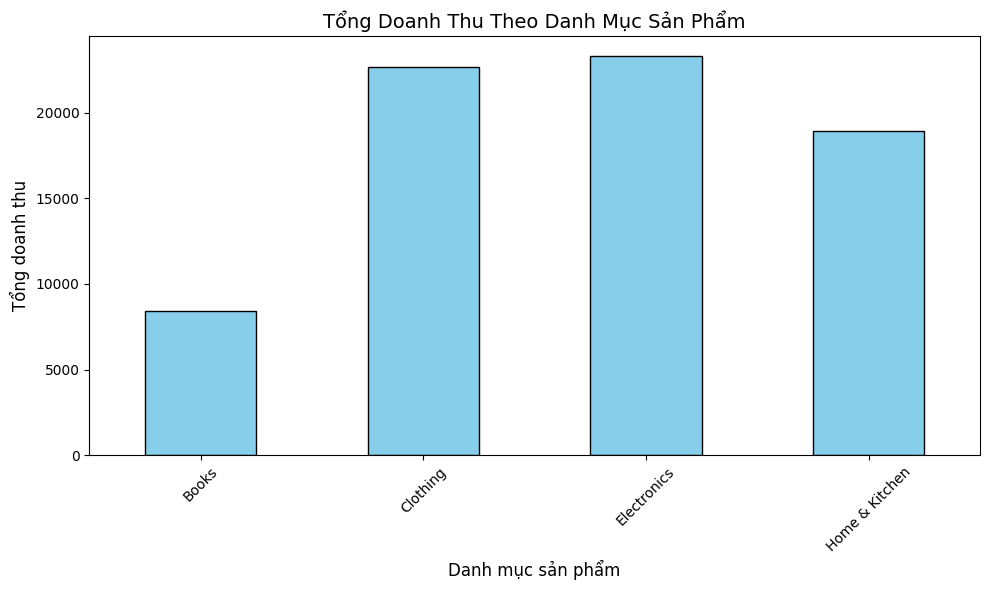

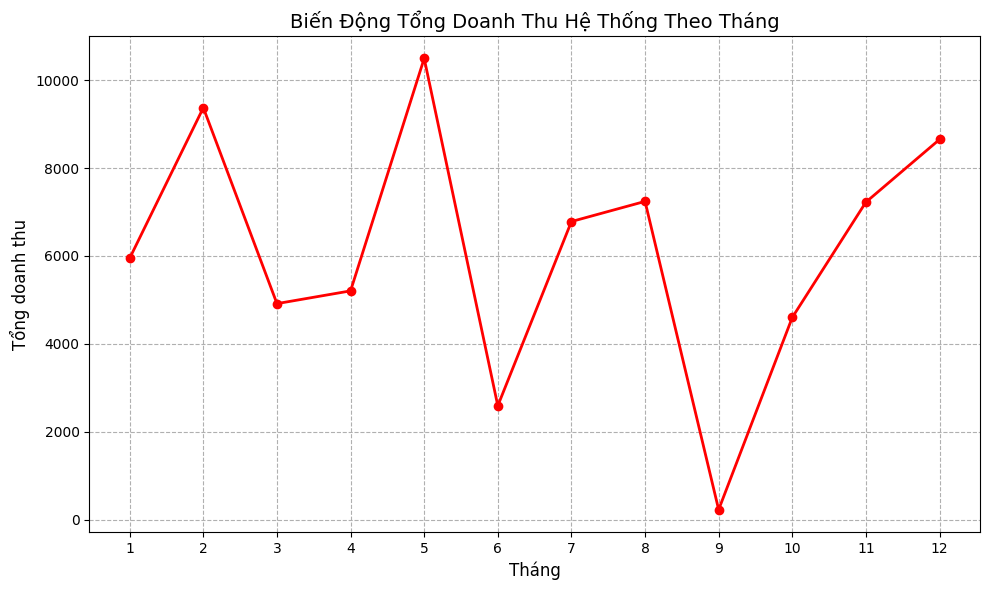

In [27]:
# Cài đặt kích thước mặc định cho biểu đồ
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Biểu đồ cột (Bar chart): Tổng doanh thu theo Danh mục sản phẩm
revenue_by_cat = df.groupby('Product_Category')['Revenue'].sum()

plt.figure()
revenue_by_cat.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Tổng Doanh Thu Theo Danh Mục Sản Phẩm', fontsize=14)
plt.xlabel('Danh mục sản phẩm', fontsize=12)
plt.ylabel('Tổng doanh thu', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Biểu đồ đường (Line chart): Sự biến động tổng doanh thu qua các tháng
revenue_by_month = df.groupby('Month')['Revenue'].sum().sort_index()

plt.figure()
plt.plot(revenue_by_month.index, revenue_by_month.values, marker='o', color='red', linewidth=2)
plt.title('Biến Động Tổng Doanh Thu Hệ Thống Theo Tháng', fontsize=14)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tổng doanh thu', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()